In [3]:
import numpy as np
import pandas as pd
import os
import sys
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import country_converter as coco
import geopandas as gpd

parent_dir = os.path.abspath("..")
sys.path.insert(0, parent_dir)

import numpy as np
import pandas as pd

from experiments import utils
from package_name.model.utils import sampling
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor

import matplotlib.pyplot as plt
import plotly.express as px
plt.style.use("dark_background")



/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
I0000 00:00:1782911480.311477 3210474 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782911480.312428 3210474 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782911480.372068 3210474 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782911482.897653 3210474 port.cc:153] oneDNN custom operations are on. You ma

## Parameters

In [37]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
filepath = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 50


## Data pre-processing

In [38]:
#create clusters for the wind data using kmeans and save the cluster labels in a csv file
path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_country_wise.csv"

df_in = pd.read_csv(path, comment="#")
#select dates > 1980 and < 2023 in extended winter
df_in["Date"] = pd.to_datetime(df_in["Date"])
df_in = df_in[(df_in["Date"].dt.year > 1980) & (df_in["Date"].dt.year < 2023)]
df_in = df_in[df_in["Date"].dt.month.isin(extended_winter_months)]
#remove date column and empty countries and reset index
df_in = df_in.drop(columns=["Date"])
df_in = df_in.dropna(axis=1, how="all")
df_in = df_in.reset_index(drop=True)

#TODO: some standardization might make sense
df = pd.DataFrame(
    SimpleImputer(strategy="mean").fit_transform(df_in),
    columns=df_in.columns,
)
X = df_in.values
#subtrct mean and divide by std for each column and overwrite df with the normalized values
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
df_in_norm = pd.DataFrame(X, columns=df_in.columns)
clusters = KMeans(n_clusters=4, random_state=0).fit(X)
cluster_labels = clusters.predict(X)
dic = {"labels": cluster_labels}
df_clusters = pd.DataFrame(data = dic)

df_clusters.to_csv("/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_clusters_norm.csv")


In [39]:
#count the number of samples in each cluster and print it
print(df_clusters["labels"].value_counts())

labels
1    2453
0    1469
3    1362
2    1068
Name: count, dtype: int64


In [40]:
#select days belonging to each cluster and calculate the mean of each cluster and put into df_cluster_means
df_cluster_means = pd.DataFrame(columns=df_in_norm.columns)
for i in range(4):
    cluster_i = df_in_norm[df_clusters["labels"] == i]
    cluster_i_mean = cluster_i.mean()
    df_cluster_means.loc[i] = cluster_i_mean

In [8]:
# Extract the column labels as a list of strings
column_labels = df_in.columns.astype(str).tolist()


In [9]:
import pandas as pd
import country_converter as coco
import plotly.express as px

# 1. Loop through all 5 rows (clusters 0 to 4) and stack them into a single list
plot_data_list = []
for cluster_id in range(4):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': df_cluster_means.loc[cluster_id].values,
        'cluster': f"Regime {cluster_id}" # Label each row with its specific cluster ID
    })
    plot_data_list.append(df_temp)

# Combine all 5 clusters into one master DataFrame
df_plot = pd.concat(plot_data_list, ignore_index=True)

# 2. Instantiate the converter
cc = coco.CountryConverter()

# 3. Convert the ISO-2 labels column to ISO-3 strings
# (Passing it as a list is faster for large combined dataframes)
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# 4. Build the Grid of Choropleth Maps
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",          # CRUCIAL: Tells Plotly to create a map for each cluster
    #facet_col_spacing=0,            # Reduces the gap between maps for a more cohesive look
    #facet_col_wrap=3,             # Arranges them in a clean grid (3 maps on top row, 2 on the bottom)
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="European Energy Clusters"
)

# 5. Pro-Optimization for Grid Layouts
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, # Giving it extra height so a 2-row grid isn't vertically squished
    width=600, # Wider width to accommodate 3 maps in the top row without overlap

    coloraxis_colorbar=dict(
        title="Metric Scale",     # Label for the scale
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",           # Thinner bar (default is usually 30)
        lenmode="fraction",
        len=0.5,                  # Takes up only 60% of the map height instead of 100%
        yanchor="middle",         # Centers it vertically
        y=-0.1
    )
)

fig.show()

In [11]:
# Get training data
z500 = utils.preprocess_dataset(filename ='/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv('/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_clusters_norm.csv')
pr_labels.columns = ['index', 'labels']
#pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

## Define model

In [41]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

#Define loss factors for the VAE model
dirichlet_loss_factor = 2
reconstruction_loss_factor = 1
regularisation_loss_factor = 1
target_prediction_loss_factor = 1#0.25
cluster_target_regularisation_loss_factor = 5#5
mixture_regularization_loss_factor = 2#10


#TODO: add possibility to specify other loss factors, e.g., reconstruction loss factor, dirichlet loss factor, etc.
vae = VAETrainer(cfg=config,  path_to_save_weights=filepath, dirichlet_loss_factor=dirichlet_loss_factor, reconstruction_loss_factor=reconstruction_loss_factor, regularisation_loss_factor=regularisation_loss_factor, target_prediction_loss_factor=target_prediction_loss_factor, cluster_target_regularisation_loss_factor=cluster_target_regularisation_loss_factor, mixture_regularization_loss_factor=mixture_regularization_loss_factor)
vae.compile()

history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(filepath+'final_weights_'+str(cluster_number)+'.weights.h5')

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - cluster_target_regularisation_loss: 0.1340 - mixture_regularization_loss: 11.8624 - reconstruction_loss: 448.7700 - target_prediction_loss: 4.7587 - total_loss: 492.1270 - vae_regularisation_loss: 14.2035 - val_cluster_target_regularisation_loss: 0.1788 - val_mixture_regularization_loss: 11.7942 - val_reconstruction_loss: 257.9406 - val_target_prediction_loss: 4.7338 - val_total_loss: 309.4477 - val_vae_regularisation_loss: 22.2908
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - cluster_target_regularisation_loss: 0.1524 - mixture_regularization_loss: 11.6741 - reconstruction_loss: 195.5511 - target_prediction_loss: 4.5460 - total_loss: 245.1777 - vae_regularisation_loss: 20.9705 - val_cluster_target_regularisation_loss: 0.1462 - val_mixture_regularization_loss: 11.6203 - val_reconstruction_loss: 144.9965 - val_target_prediction_loss: 4.5299 - val_total_loss: 196.6012 - val_vae_regularisation_loss: 23.1032
Epoch 3/50
35/35 ━━━━━

## Plot training and validation losses.

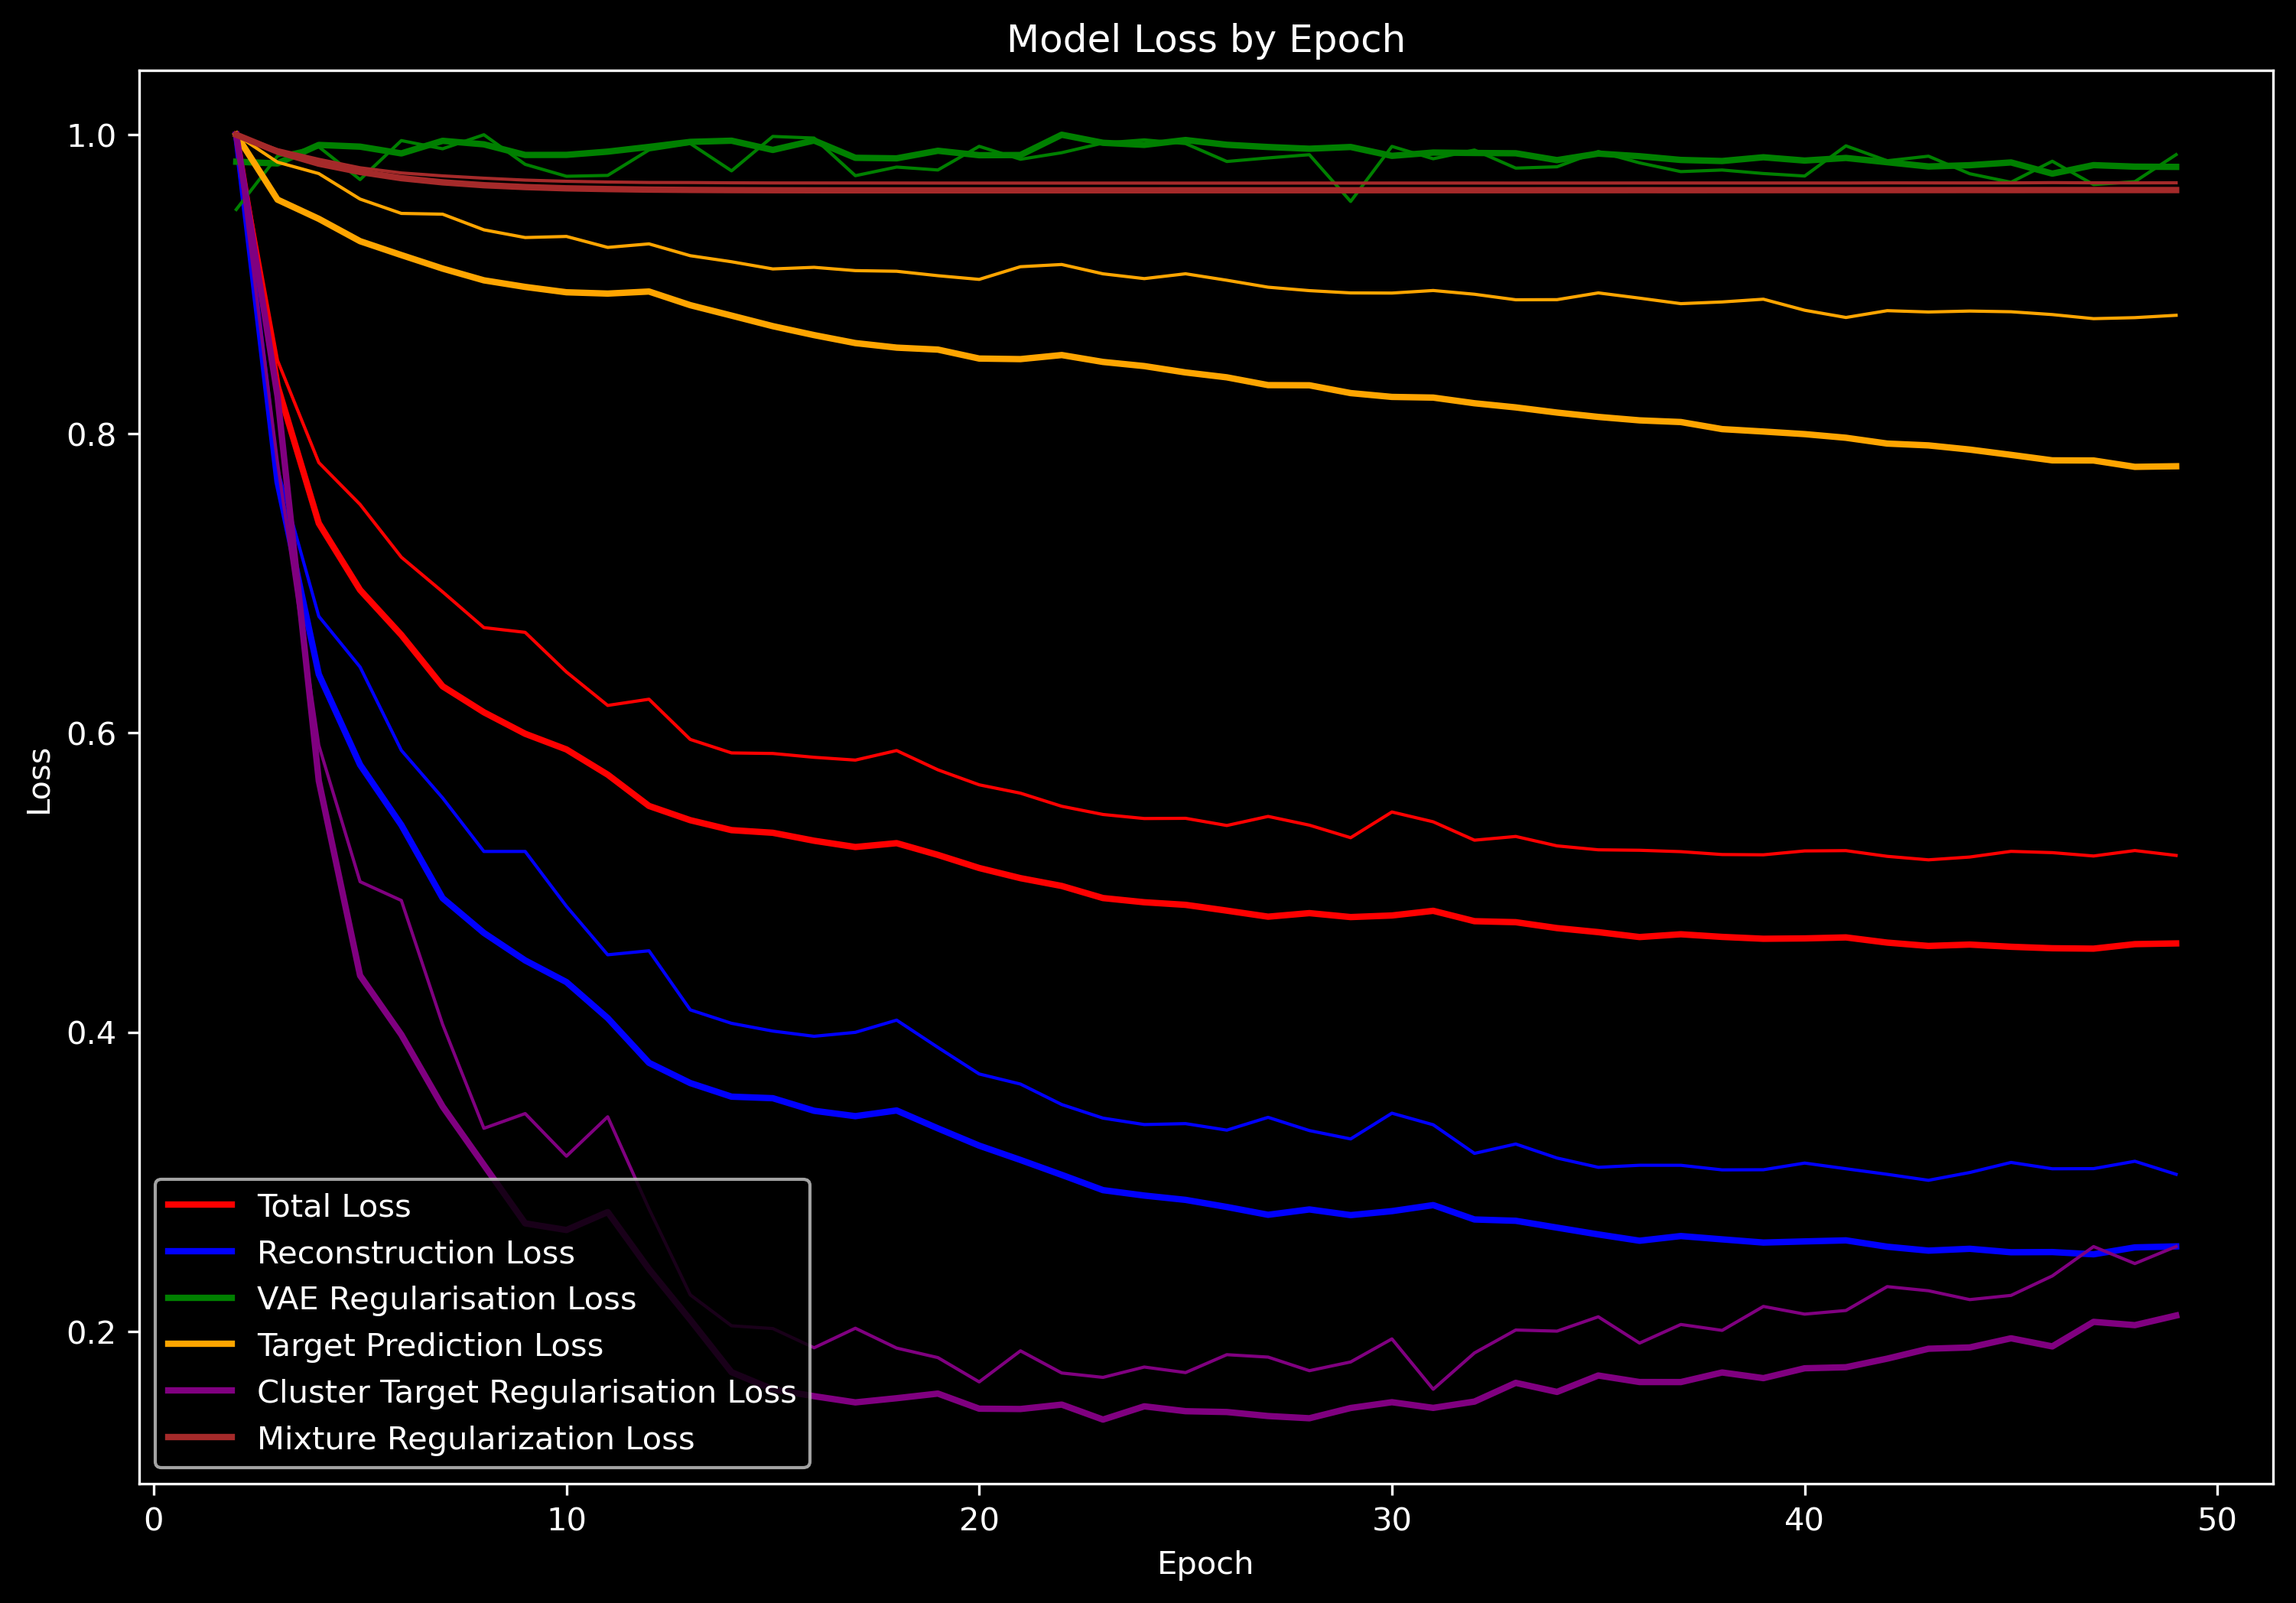

In [42]:
utils.plot_all_losses(history=history)

## Cross validation

In [10]:
cross_validator = CrossValidator(vae=vae,filepath=filepath,cluster_number=cluster_number,n_runs=3)
histories = cross_validator.run(X=z500.values,y=label_indices,epochs=epochs, batch_size=batch_size)

Epoch 1/80
 5/35 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - cluster_target_regularisation_loss: 0.1648 - mixture_regularization_loss: 9.1034 - reconstruction_loss: 428.6849 - target_prediction_loss: 8.7800 - total_loss: 549.3032 - vae_regularisation_loss: 7.2393

/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - cluster_target_regularisation_loss: 0.0433 - mixture_regularization_loss: 8.8959 - reconstruction_loss: 364.9713 - target_prediction_loss: 6.7027 - total_loss: 453.2304 - vae_regularisation_loss: 8.0084 - val_cluster_target_regularisation_loss: 0.0275 - val_mixture_regularization_loss: 8.5626 - val_reconstruction_loss: 269.0442 - val_target_prediction_loss: 6.7120 - val_total_loss: 364.8750 - val_vae_regularisation_loss: 17.3945
Epoch 2/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - cluster_target_regularisation_loss: 0.0294 - mixture_regularization_loss: 8.4146 - reconstruction_loss: 203.7070 - target_prediction_loss: 6.1912 - total_loss: 294.1497 - vae_regularisation_loss: 17.1743 - val_cluster_target_regularisation_loss: 0.0257 - val_mixture_regularization_loss: 8.3068 - val_reconstruction_loss: 157.9932 - val_target_prediction_loss: 6.2743 - val_total_loss: 251.5471 - val_vae_regularisation_loss: 19.9353
Epoch 3/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

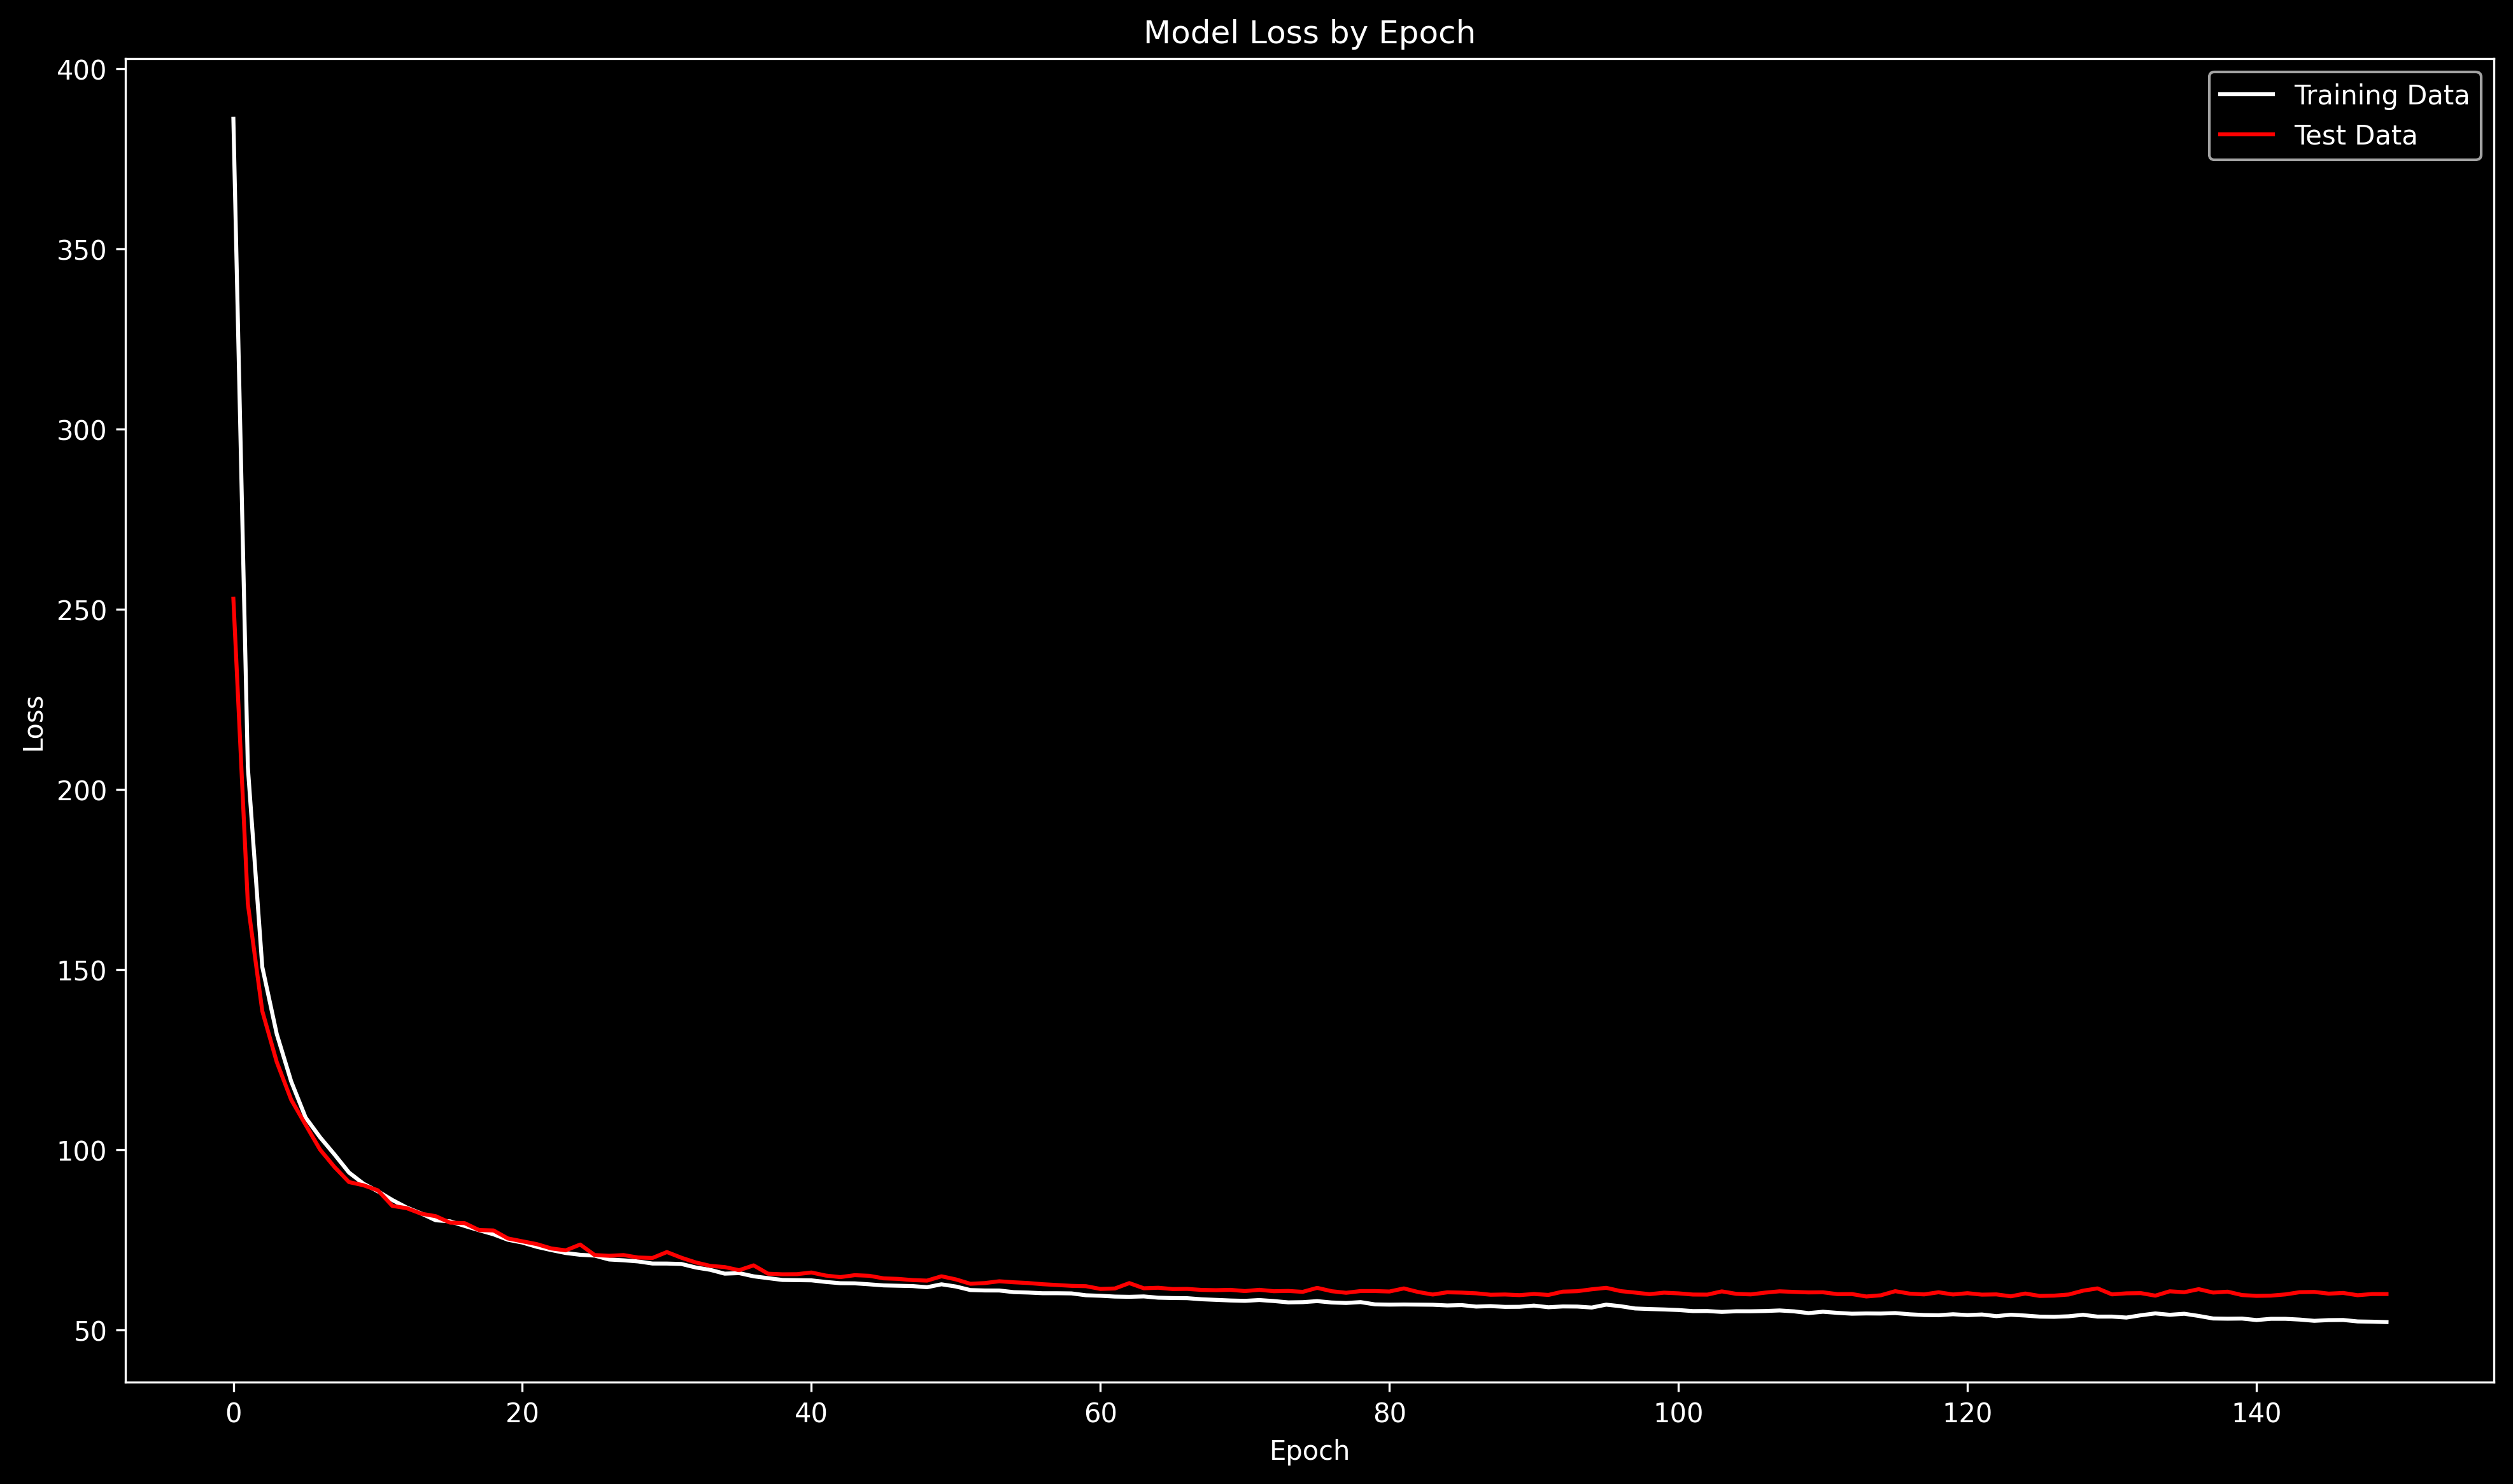

In [11]:
number = 1

training_loss = histories[number].history['loss']
validation_loss = histories[number].history['val_loss']
utils.plot_losses(training_loss, validation_loss)

## Evaluation

In [43]:
path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_country_wise.csv"

df = pd.read_csv(path, comment="#")
#select dates > 1980 and < 2023 in extended winter
df["Date"] = pd.to_datetime(df["Date"])
df = df[(df["Date"].dt.year > 1980) & (df["Date"].dt.year < 2023)]
df = df[df["Date"].dt.month.isin(extended_winter_months)]
#remove date column and empty countries and reset index
df = df.drop(columns=["Date"])
df = df.dropna(axis=1, how="all")
df = df.reset_index(drop=True)

#TODO: some standardization might make sense
df = pd.DataFrame(
    SimpleImputer(strategy="mean").fit_transform(df),
    columns=df.columns,
)

X = df.values
#subtrct mean and divide by std for each column and overwrite df with the normalized values
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
df_in_norm = pd.DataFrame(X, columns=df.columns)

In [44]:
cluster_number = 4

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

vae = VAEPredictor(cfg=config,  dirichlet_loss_factor=dirichlet_loss_factor, reconstruction_loss_factor=reconstruction_loss_factor, regularisation_loss_factor=regularisation_loss_factor, target_prediction_loss_factor=target_prediction_loss_factor, cluster_target_regularisation_loss_factor=cluster_target_regularisation_loss_factor, mixture_regularization_loss_factor=mixture_regularization_loss_factor)
#vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'_'+str(0)+'.weights.h5')
vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'.weights.h5')

In [45]:
X_all = z500.values.reshape(z500.values.shape[0], -1, order='F')
input = {
    "x": X_all,
    "dummy": np.ones((X_all.shape[0], 1)),
    "target": np.zeros((X_all.shape[0], vae.cfg.pr_cluster_number)),
}

In [46]:
encoded = vae.encode(input, batch_size=batch_size)
cluster_probs = encoded['clusters']['clusters_pred']
cluster_label = np.argmax(cluster_probs, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [47]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

In [48]:
cluster_probs

array([[0.00591264, 0.06558545, 0.76367843, 0.1648235 ],
       [0.00725355, 0.03843586, 0.6885601 , 0.26575047],
       [0.01622809, 0.03792745, 0.50955194, 0.4362926 ],
       ...,
       [0.01850299, 0.1040915 , 0.70217216, 0.17523326],
       [0.01965903, 0.10614458, 0.7037647 , 0.17043178],
       [0.01447059, 0.08977892, 0.73561424, 0.1601362 ]],
      shape=(6352, 4), dtype=float32)

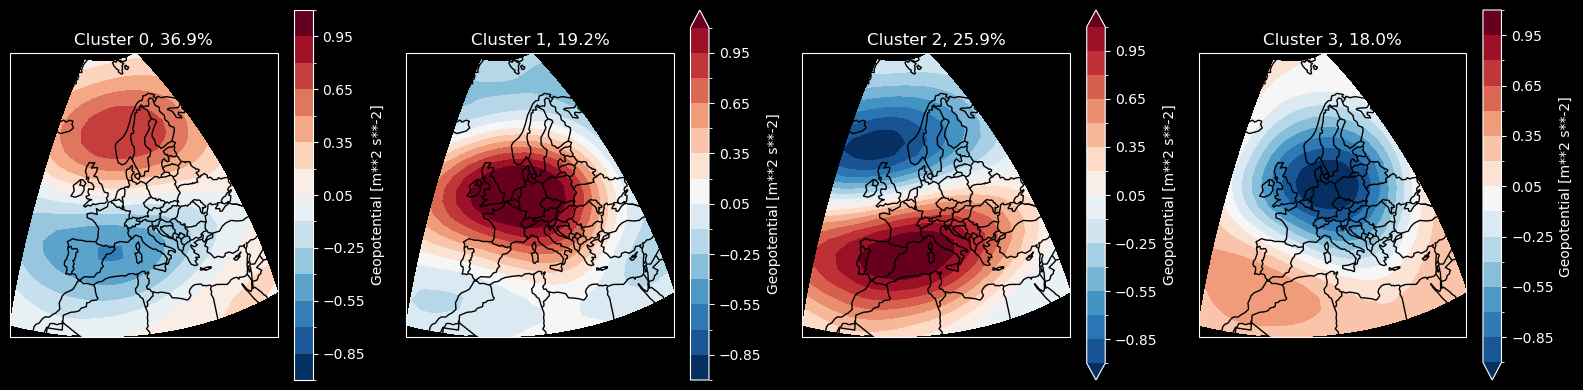

In [49]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

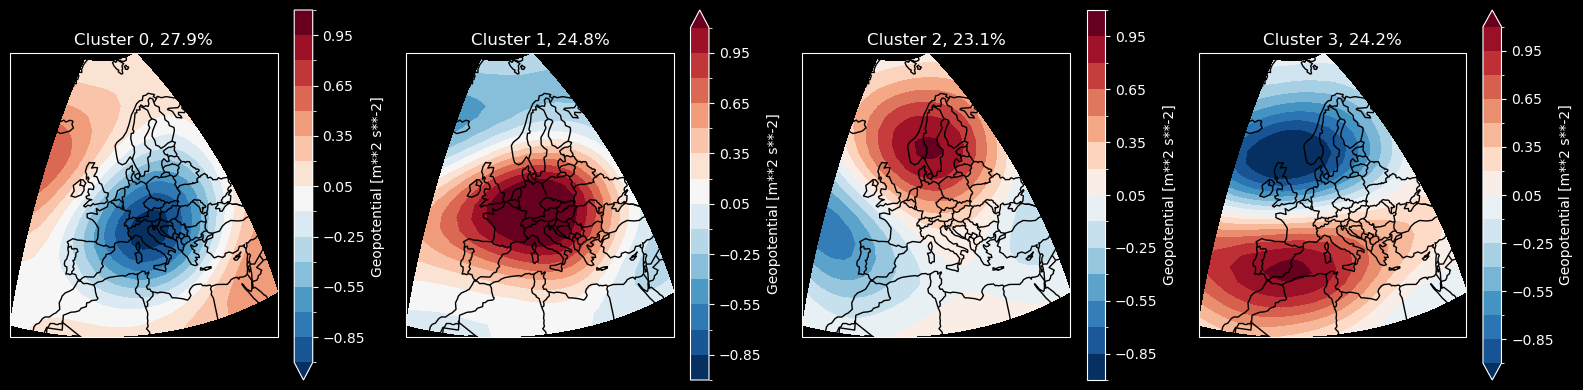

In [22]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

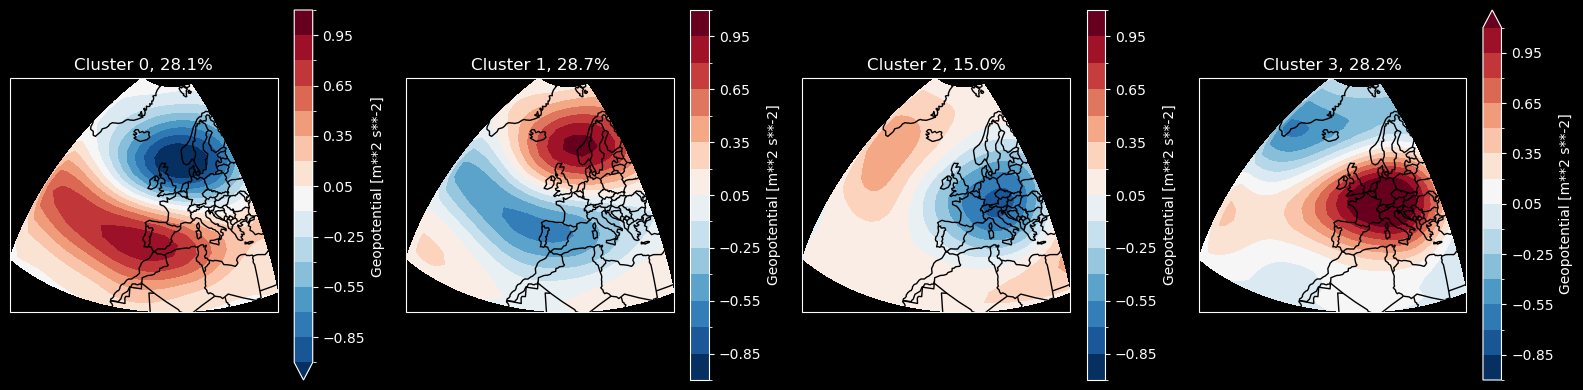

In [125]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

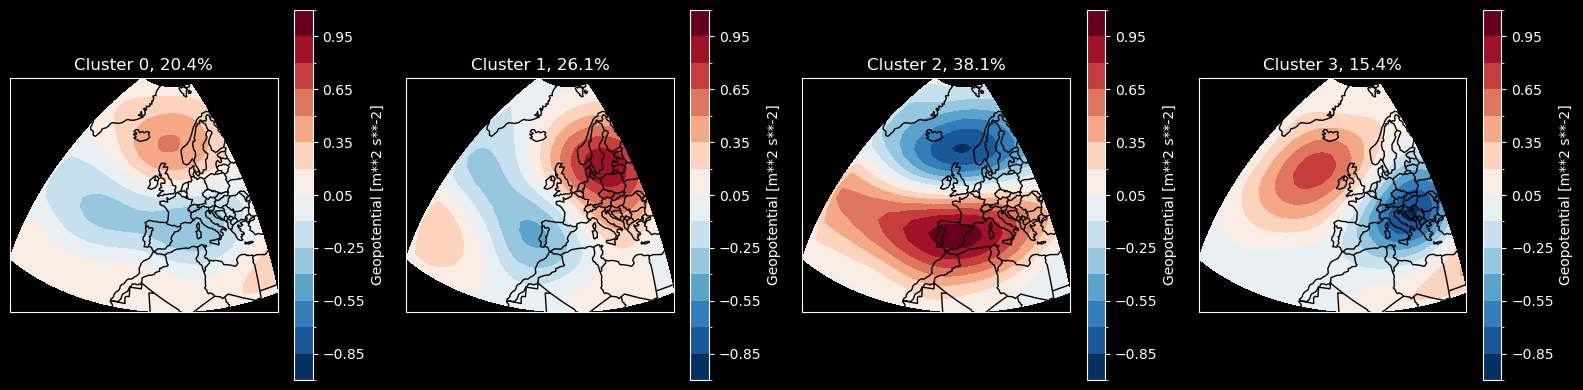

In [63]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

In [50]:
wind_energy_means = df_in_norm.groupby(z500_with_label.label.values).mean()

In [51]:
import pandas as pd
import country_converter as coco
import plotly.express as px

column_labels = df.columns.astype(str).tolist()
# 1. Loop through all 5 rows (clusters 0 to 4) and stack them into a single list
plot_data_list = []
for cluster_id in range(cluster_number):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': wind_energy_means.loc[cluster_id].values,
        'cluster': f"Regime {cluster_id}" # Label each row with its specific cluster ID
    })
    plot_data_list.append(df_temp)

# Combine all 5 clusters into one master DataFrame
df_plot = pd.concat(plot_data_list, ignore_index=True)

# 2. Instantiate the converter
cc = coco.CountryConverter()

# 3. Convert the ISO-2 labels column to ISO-3 strings
# (Passing it as a list is faster for large combined dataframes)
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# 4. Build the Grid of Choropleth Maps
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",          # CRUCIAL: Tells Plotly to create a map for each cluster
    #facet_col_spacing=0,            # Reduces the gap between maps for a more cohesive look
    #facet_col_wrap=3,             # Arranges them in a clean grid (3 maps on top row, 2 on the bottom)
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="Wind CF Clusters"
)

# 5. Pro-Optimization for Grid Layouts
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, # Giving it extra height so a 2-row grid isn't vertically squished
    width=600, # Wider width to accommodate 3 maps in the top row without overlap

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     # Label for the scale
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",           # Thinner bar (default is usually 30)
        lenmode="fraction",
        len=0.5,                  # Takes up only 60% of the map height instead of 100%
        yanchor="middle",         # Centers it vertically
        y=-0.1
    )
)

fig.show()

In [36]:
import pandas as pd
import country_converter as coco
import plotly.express as px

column_labels = df.columns.astype(str).tolist()
# 1. Loop through all 5 rows (clusters 0 to 4) and stack them into a single list
plot_data_list = []
for cluster_id in range(cluster_number):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': wind_energy_means.loc[cluster_id].values,
        'cluster': f"Regime {cluster_id}" # Label each row with its specific cluster ID
    })
    plot_data_list.append(df_temp)

# Combine all 5 clusters into one master DataFrame
df_plot = pd.concat(plot_data_list, ignore_index=True)

# 2. Instantiate the converter
cc = coco.CountryConverter()

# 3. Convert the ISO-2 labels column to ISO-3 strings
# (Passing it as a list is faster for large combined dataframes)
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# 4. Build the Grid of Choropleth Maps
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",          # CRUCIAL: Tells Plotly to create a map for each cluster
    #facet_col_spacing=0,            # Reduces the gap between maps for a more cohesive look
    #facet_col_wrap=3,             # Arranges them in a clean grid (3 maps on top row, 2 on the bottom)
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="Wind CF Clusters"
)

# 5. Pro-Optimization for Grid Layouts
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, # Giving it extra height so a 2-row grid isn't vertically squished
    width=600, # Wider width to accommodate 3 maps in the top row without overlap

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     # Label for the scale
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",           # Thinner bar (default is usually 30)
        lenmode="fraction",
        len=0.5,                  # Takes up only 60% of the map height instead of 100%
        yanchor="middle",         # Centers it vertically
        y=-0.1
    )
)

fig.show()

In [32]:
import pandas as pd
import country_converter as coco
import plotly.express as px

column_labels = df.columns.astype(str).tolist()
# 1. Loop through all 5 rows (clusters 0 to 4) and stack them into a single list
plot_data_list = []
for cluster_id in range(cluster_number):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': wind_energy_means.loc[cluster_id].values,
        'cluster': f"Regime {cluster_id}" # Label each row with its specific cluster ID
    })
    plot_data_list.append(df_temp)

# Combine all 5 clusters into one master DataFrame
df_plot = pd.concat(plot_data_list, ignore_index=True)

# 2. Instantiate the converter
cc = coco.CountryConverter()

# 3. Convert the ISO-2 labels column to ISO-3 strings
# (Passing it as a list is faster for large combined dataframes)
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# 4. Build the Grid of Choropleth Maps
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",          # CRUCIAL: Tells Plotly to create a map for each cluster
    #facet_col_spacing=0,            # Reduces the gap between maps for a more cohesive look
    #facet_col_wrap=3,             # Arranges them in a clean grid (3 maps on top row, 2 on the bottom)
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="Wind CF Clusters"
)

# 5. Pro-Optimization for Grid Layouts
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, # Giving it extra height so a 2-row grid isn't vertically squished
    width=600, # Wider width to accommodate 3 maps in the top row without overlap

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     # Label for the scale
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",           # Thinner bar (default is usually 30)
        lenmode="fraction",
        len=0.5,                  # Takes up only 60% of the map height instead of 100%
        yanchor="middle",         # Centers it vertically
        y=-0.1
    )
)

fig.show()

In [161]:
wind_energy_means

,AL,AT,BA,BE,BG,CH,CY,CZ,DE,DK,...,NO,PL,PT,RO,RS,SE,SI,SK,TR,UK
0,0.126032,0.189913,0.105400,-0.032050,0.172566,0.093467,0.146943,0.034552,-0.041656,-0.109101,...,-0.203958,-0.119775,0.079876,0.127664,0.158718,-0.252618,0.012561,0.114526,0.243828,-0.018151
1,-0.143083,-0.049260,-0.188286,0.110917,-0.010205,-0.209292,0.074424,-0.011587,0.092858,0.281718,...,0.338093,0.084934,-0.471285,-0.062395,-0.183007,0.279406,-0.167670,-0.117429,-0.055545,0.411920
2,0.239496,-0.180034,0.070488,-0.500926,0.050657,-0.151204,-0.065904,-0.271564,-0.494467,-0.784978,...,-0.566955,-0.489188,-0.129269,-0.025747,-0.038391,-0.550961,0.384863,-0.050653,-0.117561,-0.671715
3,-0.014495,-0.047203,0.015407,-0.000312,-0.067804,0.037735,-0.068924,0.003797,0.017525,0.007337,...,0.023636,0.047768,0.063260,-0.035731,-0.013107,0.057956,0.035846,-0.011690,-0.077068,-0.067962
4,0.017930,0.097875,-0.055307,0.041182,0.206657,-0.118620,0.073556,-0.012513,-0.131747,-0.221467,...,-0.377633,-0.181968,0.668339,0.196110,0.186031,-0.441389,-0.201707,0.123307,0.289996,-0.104973


In [ ]:
#plot wind energy for each cluster


In [ ]:
# save cluster centers

z500_labels_preciporder = z500.assign_coords(label=("time", labels_reordered))/weights
z500_labels = z500.assign_coords(label=("time", final_labels))/weights

means_preciporder = z500_labels_preciporder.groupby('label').mean()
means = z500_labels.groupby('label').mean()

means_flat = cf.reshape_data_for_clustering(means)
means_flat_preciporder = cf.reshape_data_for_clustering(means_preciporder)

df1 = pd.DataFrame(data=means_flat)
df1.to_csv(filepath+'cluster_centers_'+str(cluster_number)+'.csv')

df2 = pd.DataFrame(data=means_flat_preciporder)
df2.to_csv(filepath+'cluster_centers_'+str(cluster_number)+'_preciporder.csv')

## Visualize the clusters